[-32.-96.j  43.+14.j  82.-59.j ...  -3.+45.j 124.-54.j -92.+41.j]


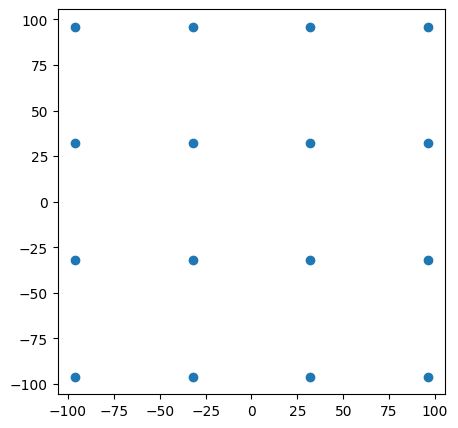

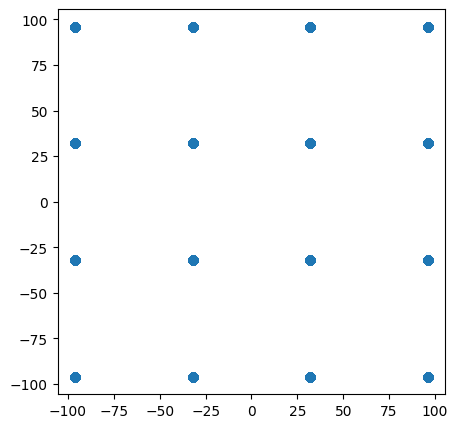

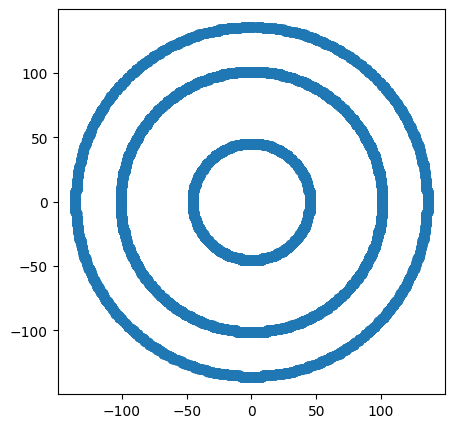

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import math as m
import math
import numpy as np
import os
import random

# script_dir = os.path.dirname(os.path.abspath(__file__))
script_dir = os.getcwd()
output_file_in  = os.path.join(script_dir, "../../RTL/carrier_recovery/input_data.txt")
output_file_out = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output.txt")
output_file_out_atan_r = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_atan_r.txt")
output_file_out_atan_a = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_atan_a.txt")
output_file_out_phase_err = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_phase_err.txt")

qam16_constellation = {
    0: (-96, -96), 1: (-96, -32), 2: (-96, 32), 3: (-96, 96),
    4: (-32, -96), 5: (-32, -32), 6: (-32, 32), 7: (-32, 96),
    8: (32, -96), 9: (32, -32), 10: (32, 32), 11: (32, 96),
    12: (96, -96), 13: (96, -32), 14: (96, 32), 15: (96, 96)
}

# k = np.real( complex(1,0) * np.exp(1j*np.deg2rad(45)) ) / 3

# print(k)

# qam16_constellation = {key: (k * I, k * Q) for key, (I, Q) in qam16_constellation.items()}

symbols=np.array([complex(i,q) for i,q in qam16_constellation.values()])
plt.figure(figsize=(5,5))
plt.scatter(np.real(symbols), np.imag(symbols))

n_samples=20000

indices = np.random.randint(0, len(symbols), n_samples)
tx_symbols = symbols[indices]
# tx_symbols = symbols[1]
plt.figure(figsize=(5,5))
plt.scatter(np.real(tx_symbols), np.imag(tx_symbols))

freq_offset = 10*np.pi/180

n = np.arange(n_samples)
rx_symbols = np.round(tx_symbols * np.exp(1j * 2 * np.pi * freq_offset * n))

plt.figure(figsize=(5,5))
plt.scatter(np.real(rx_symbols), np.imag(rx_symbols))

print(rx_symbols)

Damping Ratio (ζ): 1.1181704925033795
Overdamped (Slow Response): ζ>1
atan(-96.0/-32.0) = -1.89251708984375
atan(-96.0/-32.0) = -1.89251708984375


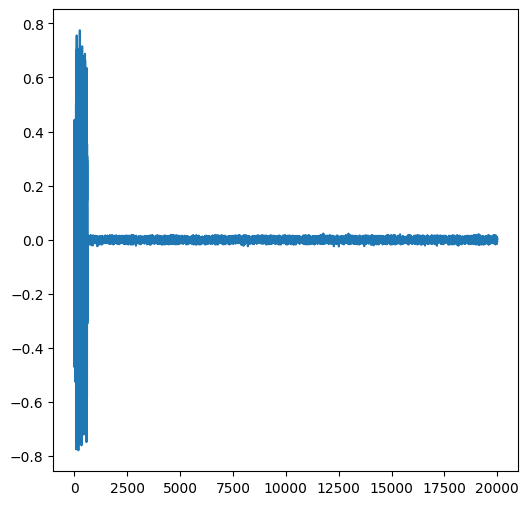

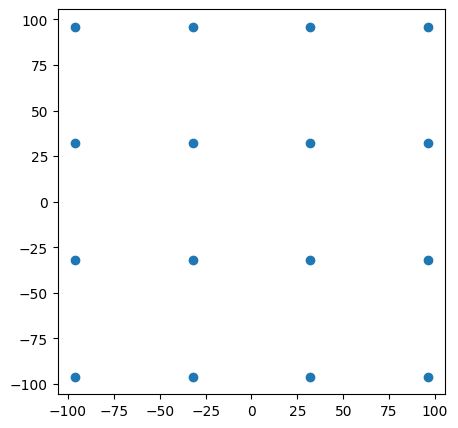

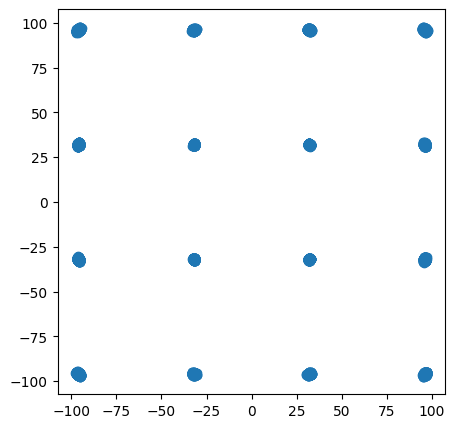

In [149]:
recovered_symbols = np.zeros(n_samples, dtype=complex)

Kp = 0.5  
Ki = round(0.05*2**14)/2**14 
zeta = Kp / (2 * np.sqrt(Ki))

print(f"Damping Ratio (ζ): {zeta}")
if(zeta < 1):
        print("Underdamped (Oscillatory Response): ζ<1")
elif (zeta == 1):
        print("Critically Damped (Fastest No-Overshoot Response): ζ=1")
else:
        print("Overdamped (Slow Response): ζ>1")

phase_nco = 0  
freq_nco = 0   
integrator = 0 
phase_errors = np.zeros(n_samples)
freq_nco_i = np.zeros(n_samples)
phase_nco_i = np.zeros(n_samples)
symbol_a = complex(0)

def slicer(i_received_symbol):
        if (i_received_symbol < -64): 
                return -96
        elif (i_received_symbol < 0): 
                return -32
        elif (i_received_symbol < 64):  
                return 32 
        else:  
                return 96
               
def f_integer(bits, number):
        return int(number) & ((1 << bits) - 1)


with open(output_file_in, "w") as f_in, open(output_file_out, "w") as f_out, open(output_file_out_atan_r, "w") as f_out_atan_r ,open(output_file_out_atan_a, "w") as f_out_atan_a , open(output_file_out_phase_err, "w") as f_out_phase_err:

        for i in range(n_samples): 
                a = round(np.real(rx_symbols[i])*2**7)/2**7
                b = round(np.imag(rx_symbols[i])*2**7)/2**7
                x = round(phase_nco*2**7)/2**7
                cosx= round(np.cos(x)*2**7)/2**7
                sinx= round(np.sin(x)*2**7)/2**7
                
                write_a = f_integer(8, a)
                write_b = f_integer(8, b) 
                        
                f_in.write(f"{int(write_b)} {int(write_a)}\n")
                
                real_corrected = round((a * cosx)*2**7)/2**7 + round((b * sinx)*2**7)/2**7
                imag_corrected = round((b * cosx)*2**7)/2**7 - round((a * sinx)*2**7)/2**7
                
                write_a = f_integer(8, real_corrected) 
                write_b = f_integer(8, imag_corrected) 
                
                f_out.write(f"{int(write_b)} {int(write_a)}\n")
                
                corrected_symbol = real_corrected + 1j * imag_corrected
                # corrected_symbol = rx_symbols[i] * np.exp(-1j * phase_nco)

                phase_r = round((m.atan2(np.imag(corrected_symbol), np.real(corrected_symbol)))*2**14)/2**14
                f_out_atan_r.write(f"{round(phase_r*2**14)}\n")
                
                if i==0:
                        print(f"atan({np.imag(corrected_symbol)}/{np.real(corrected_symbol)}) = {phase_r}")
                
                symbol_a = slicer(np.real(corrected_symbol)) + 1j * slicer(np.imag(corrected_symbol))
                phase_a = round((m.atan2(np.imag(symbol_a),np.real(symbol_a)))*2**14)/2**14
                f_out_atan_a.write(f"{round(phase_a*2**14)}\n")
                if i==0:
                        print(f"atan({np.imag(symbol_a)}/{np.real(symbol_a)}) = {phase_a}")
                
                # closest_symbol = symbols[np.argmin(abs(symbols - corrected_symbol))]
                # phase_error = np.angle(corrected_symbol * np.conj(closest_symbol))
                phase_error = phase_r - phase_a
                phase_errors[i] = phase_error
                f_out_phase_err.write(f"{round(phase_error*2**14)}\n")

                integrator += round(Ki * phase_error*2**14)/2**14
                
                if integrator <= -2*np.pi:
                        integrator = integrator+2*np.pi
                elif integrator >= 2*np.pi:
                        integrator = integrator-2*np.pi
                
                freq_nco = round(Kp * phase_error*2**14)/2**14 + integrator          
                freq_nco_i[i] = freq_nco
                
                phase_nco += freq_nco  
                
                if phase_nco <= -2*np.pi:
                        phase_nco = phase_nco+2*np.pi
                elif phase_nco >= 2*np.pi:
                        phase_nco = phase_nco-2*np.pi
                
                phase_nco_i[i] = phase_nco
                
                recovered_symbols[i] = corrected_symbol

# plt.figure(figsize=(12,6))
# plt.plot( range(n_samples), freq_nco_i)
# plt.xlim(0,2000)

# plt.figure(figsize=(12,6))
# plt.plot( range(n_samples), phase_nco_i)
# plt.xlim(1750,2000)

plt.figure(figsize=(6,6))
plt.plot( range(n_samples), phase_errors)
# plt.xlim(0,1000)

plt.figure(figsize=(5,5))
plt.scatter(np.real(symbols), np.imag(symbols))

plt.figure(figsize=(5,5))
plt.scatter(np.real(recovered_symbols[10000:len(recovered_symbols)]),np.imag(recovered_symbols[10000:len(recovered_symbols)]))
